## <center> **Food Delivery Time Prediction** <center>
---

### <center> **01. Data Previewing and Understanding** </center>

### Step 1.1: Imports

In [59]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = [8, 6]

# Set the warning filter to ignore FutureWarning
warnings.simplefilter(action = "ignore", category = FutureWarning)

### Step 1.2: Load the dataset

In [60]:
df = pd.read_csv("Food_Delivery_Times.csv")

### Step 1.3: Number of Rows and Columns

In [61]:
df.shape

(1000, 9)

### Step 1.4:  First five rows

In [62]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


### Step 1.5: Last five rows

In [63]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


### Step 1.6: Five random rows

In [64]:
df.sample(5)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
62,543,4.96,Rainy,High,Morning,Bike,21,0.0,60
331,312,2.03,Foggy,High,Evening,Car,14,4.0,36
610,181,7.15,Windy,Low,Morning,Bike,15,3.0,42
45,278,13.17,Windy,Medium,Afternoon,Bike,16,4.0,67
121,426,11.22,Windy,High,Evening,Bike,25,5.0,79


### Step 1.7: Columns and their data types

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### Step 1.8: Statistical summary of the data

In [66]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


### Step 1.9: Numeric columns

In [67]:
numeric_cols = df.select_dtypes(include=["number"])

for column in numeric_cols:
    print(f"- {column}")

- Order_ID
- Distance_km
- Preparation_Time_min
- Courier_Experience_yrs
- Delivery_Time_min


### Step 1.10: Categorical columns

In [68]:
categorical_cols = df.select_dtypes(include=["object"])

for column in categorical_cols:
    print(f"- {column}")

- Weather
- Traffic_Level
- Time_of_Day
- Vehicle_Type


### Step 1.11: Number of null values in each column

In [69]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

### Step 1.12: Percentage of null values in each column

In [70]:
df.isnull().sum() / len(df) * 100

Order_ID                  0.0
Distance_km               0.0
Weather                   3.0
Traffic_Level             3.0
Time_of_Day               3.0
Vehicle_Type              0.0
Preparation_Time_min      0.0
Courier_Experience_yrs    3.0
Delivery_Time_min         0.0
dtype: float64

### <center> **0.2 Data Visualization** </center>
---

### Step 2.1: Create New feature based on `Distance_km`

In [71]:
def distance(dist):
    if dist <= 6:
        return "Low distance"
    
    elif dist <= 14:
        return "Medium distance"

    else:
        return "High distance"


df["Distance"] = df["Distance_km"].apply(distance)

### Step 2.2: Create New feature based on `Courier_Experience_yrs`

In [72]:
bins = [0, 2, 6, 9]

labels = ["Junior", "Mid-Level", "Senior"]

df["Experience_level"] = pd.cut(
    df["Courier_Experience_yrs"],
    bins= bins,
    labels=labels,
    include_lowest=True
)

df["Experience_level"] = df["Experience_level"].fillna(df["Experience_level"].mode()[0])
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Distance,Experience_level
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Medium distance,Junior
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,High distance,Junior
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Medium distance,Junior
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Medium distance,Junior
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,High distance,Mid-Level


### Step 2.3: Delivery time based on Preparation time

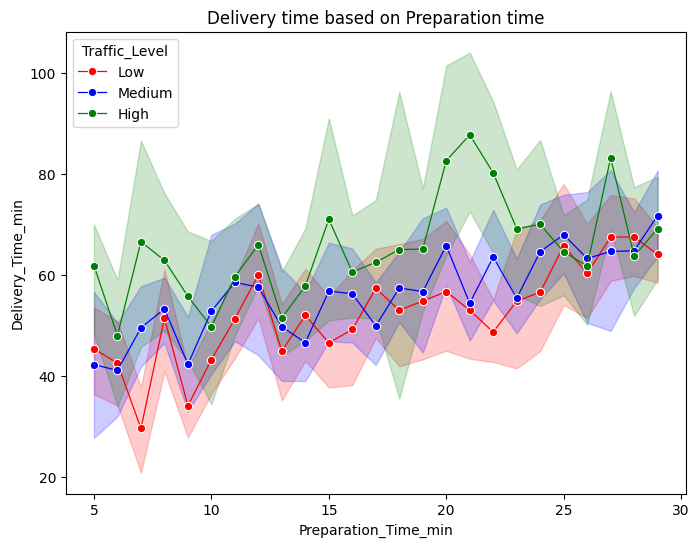

In [73]:
sns.lineplot(
    x=df["Preparation_Time_min"],
    y= df["Delivery_Time_min"],
    hue= df["Traffic_Level"],
    marker="o",
    linewidth=0.9,
    palette=["Red", "Blue", "Green"]
)

plt.title("Delivery time based on Preparation time")
plt.show()

### Step 2.4:  Delivery Time based on Traffic Level

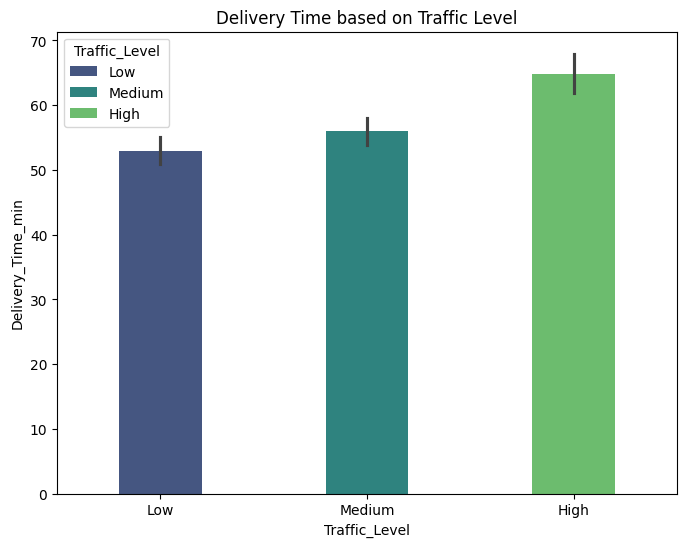

In [74]:
sns.barplot(
    x= df["Traffic_Level"],
    y= df["Delivery_Time_min"],
    hue= df["Traffic_Level"],
    palette= "viridis",
    width=0.4
)

plt.title("Delivery Time based on Traffic Level")
plt.show()

### Step 2.5:  Delivery time based on Weather

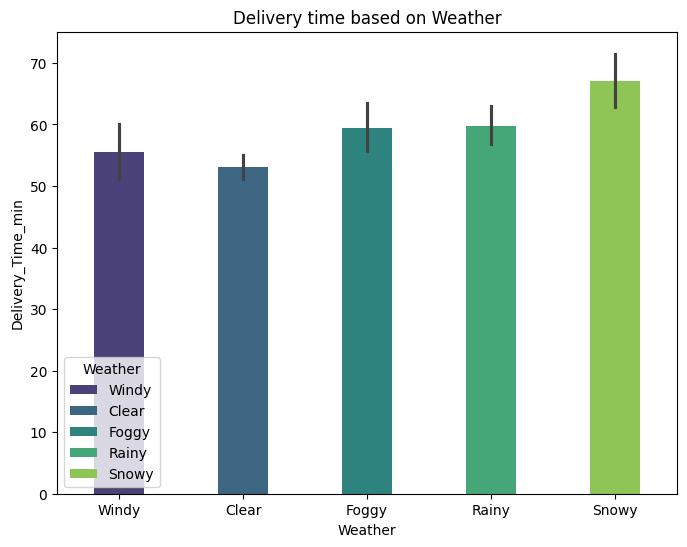

In [75]:
sns.barplot(
    x= df["Weather"],
    y= df["Delivery_Time_min"],
    hue= df["Weather"],
    palette="viridis",
    width=0.4
)

plt.title("Delivery time based on Weather")
plt.show()

### Step 2.6:  Delivery time based on Courier Experience Years

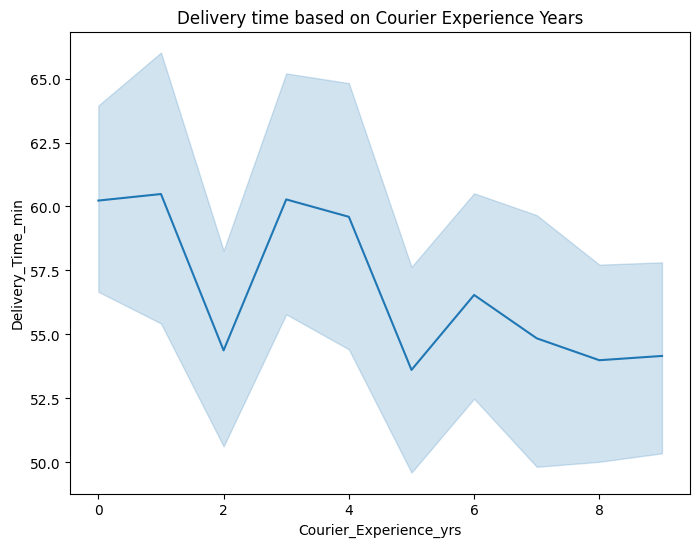

In [76]:
sns.lineplot(
    x= df["Courier_Experience_yrs"],
    y= df["Delivery_Time_min"]
)

plt.title("Delivery time based on Courier Experience Years")

plt.show()

### Step 2.7: Delivery time based on Distance

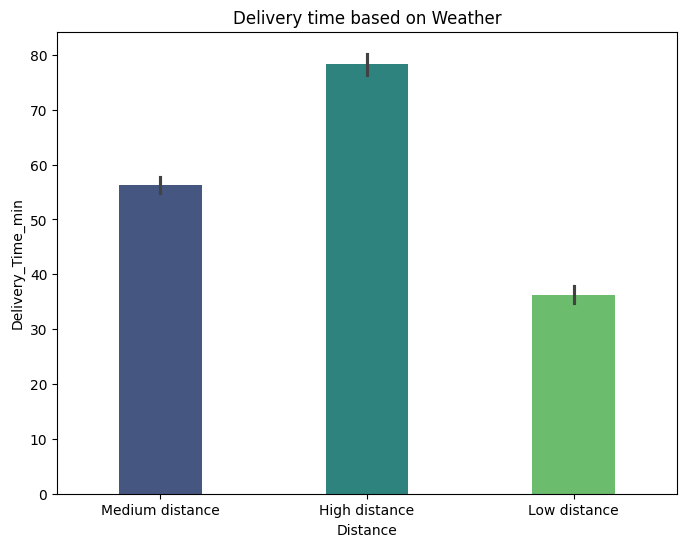

In [77]:
sns.barplot(
    x= df["Distance"],
    y= df["Delivery_Time_min"],
    hue= df["Distance"],
    palette= "viridis",
    width=0.4
)

plt.title("Delivery time based on Weather")
plt.show()

### Step 2.8: Delivery based on Time of the day

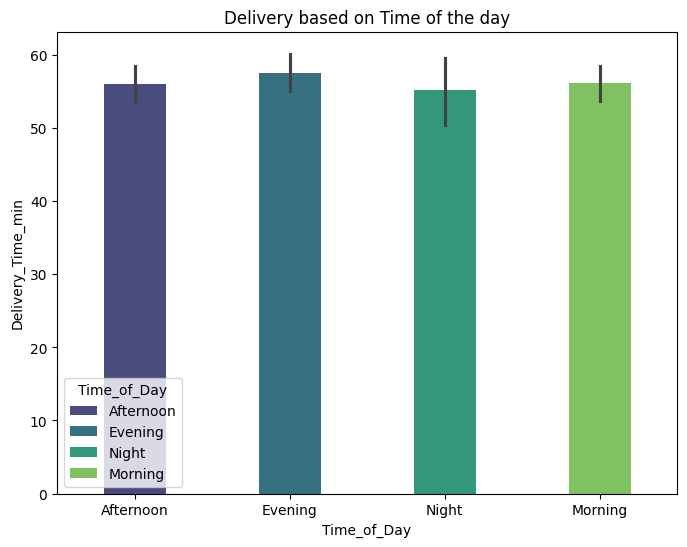

In [78]:
sns.barplot(
    x= df["Time_of_Day"],
    y= df["Delivery_Time_min"],
    hue= df["Time_of_Day"],
    palette= "viridis",
    width=0.4
)

plt.title("Delivery based on Time of the day")
plt.show()

### Step 2.9:  Delivery by Vehical Type

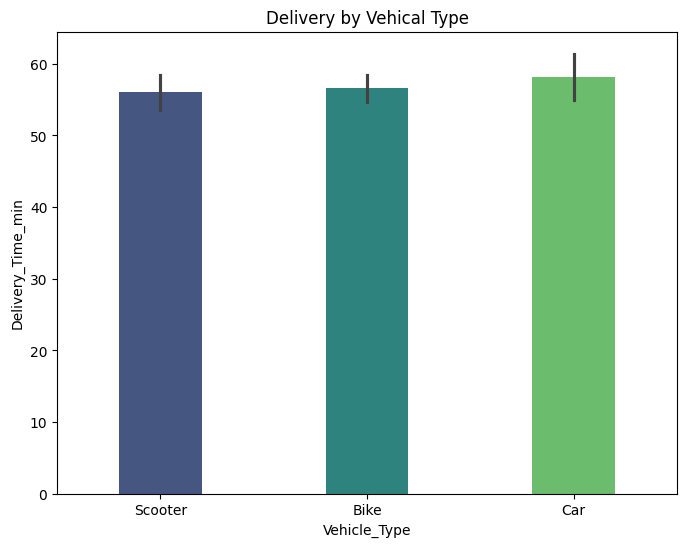

In [79]:
sns.barplot(
    x= df["Vehicle_Type"],
    y= df["Delivery_Time_min"],
    hue= df["Vehicle_Type"],
    palette="viridis",
    width=0.4
)

plt.title("Delivery by Vehical Type")
plt.show()

### Step 2.10: Delivery time based on Experience Level

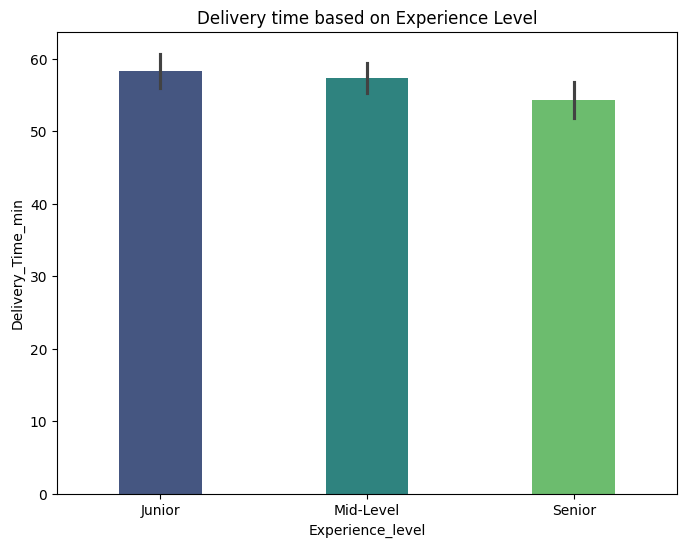

In [80]:
sns.barplot(
    x= df["Experience_level"],
    y= df["Delivery_Time_min"],
    hue= df["Experience_level"],
    palette= "viridis",
    width=0.4
)

plt.title("Delivery time based on Experience Level")

plt.show()

### Step 2.11: Visualization of missing values

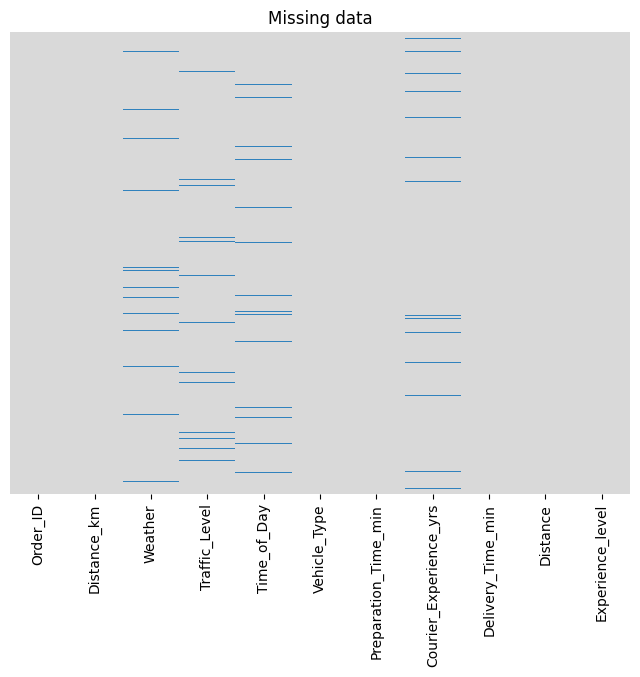

In [81]:

sns.heatmap(
    df.isnull(), 
    yticklabels=False, 
    cbar=False, 
    cmap="tab20c_r"
)

plt.title("Missing data")
plt.show()

### Step 2.12: Duplicate values

In [82]:
df.duplicated().sum()

0

- No any duplicate value

### <center> **03. Data Cleaning Preprocessing and Model Training** </center>

### Step 3.1: Remove `Order_ID`

In [83]:
df.drop("Order_ID", axis=1, inplace=True)

### Step 3.2: Features and Target

In [84]:
X = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]

### Step 3.3: Training and Test sets

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_train.shape}")

X_train shape: (800, 9)
y_train shape: (800,)
X_test shape: (200, 9)
y_test shape: (800,)


### Step 3.4: Separate Numeric and Categorical features

In [86]:
numerical_features = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs"
]
categorical_features = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type",
    "Distance",
    "Experience_level"
]

### Step 3.5: Build Preprocessing Pipeline

In [87]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

### Step 3.6: Column Transformer

In [88]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features,
            
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

### Step 3.7: Create LinearRegression Pipeline

In [89]:
pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regression",
            RandomForestRegressor(
                n_estimators=345
            )
        )
    ]
)


model = pipeline.fit(X_train, y_train)

### Step 3.8: Make Predictions

In [90]:
y_pred = model.predict(X_test)
print(y_pred)

[33.93333333 64.6115942  43.06086957 43.99710145 78.49855072 35.38550725
 66.44347826 33.56231884 32.62608696 77.39710145 74.44927536 61.07246377
 34.89565217 75.95362319 89.34492754 85.97971014 29.99130435 67.77101449
 49.70724638 58.25797101 79.32463768 30.39710145 72.35942029 73.87826087
 62.41449275 33.65217391 78.55072464 24.42318841 50.83478261 59.86086957
 68.64057971 20.02318841 56.46376812 39.78550725 73.79710145 15.76521739
 65.25507246 55.72173913 45.48115942 79.91304348 75.11594203 32.42028986
 75.28115942 65.9826087  42.68985507 19.66376812 91.47826087 80.72753623
 83.84347826 29.22028986 70.46666667 58.82608696 40.24057971 78.77971014
 54.2115942  53.24347826 76.34492754 76.26956522 61.57971014 87.41449275
 53.67246377 35.73913043 50.62318841 44.89565217 50.25507246 57.11304348
 70.86666667 89.97101449 66.41449275 56.75652174 76.70434783 37.65217391
 84.74782609 26.08695652 64.6057971  64.14202899 41.22318841 42.28695652
 49.94492754 31.28985507 60.35072464 73.91884058 62

### Step 3.9: Compare Actual and Predicted values

In [91]:
# Combine actual and predicted values side by side
results = np.column_stack((y_test, y_pred))

# Printing the results
print("Actual Values  |  Predicted Values")
print("-----------------------------")
for actual, predicted in results:
    print(f"{actual:14.2f} |  {predicted:12.2f}")

Actual Values  |  Predicted Values
-----------------------------
         32.00 |         33.93
         68.00 |         64.61
         39.00 |         43.06
         44.00 |         44.00
         85.00 |         78.50
         31.00 |         35.39
         77.00 |         66.44
         33.00 |         33.56
         90.00 |         32.63
         91.00 |         77.40
         64.00 |         74.45
         69.00 |         61.07
         38.00 |         34.90
         91.00 |         75.95
         79.00 |         89.34
         74.00 |         85.98
         26.00 |         29.99
         77.00 |         67.77
         38.00 |         49.71
         63.00 |         58.26
         87.00 |         79.32
         24.00 |         30.40
         88.00 |         72.36
         77.00 |         73.88
         57.00 |         62.41
         30.00 |         33.65
         94.00 |         78.55
         24.00 |         24.42
         51.00 |         50.83
         71.00 |         59.86
     

### Step 3.10: Evaluate model

In [92]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

Mean Squared Error: 93.26251438773366
Mean Absolute Error: 6.825724637681159
R2 Score: 0.7919301613033582


### Step 3.11: Compare Scores

In [93]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print(f"Training: {r2_train}")
print(f"Test: {r2_test}")

Training: 0.9568582729703934
Test: 0.7919301613033582


In [95]:
print(f"Mean Squared Error: {mean_squared_error(y_train, y_pred_train)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_train, y_pred_train)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

Mean Squared Error: 21.386361919764752
Mean Absolute Error: 2.9661666666666666
R2 Score: 0.7919301613033582


### Step 3.12: Save Model

In [94]:
joblib.dump(model, "delivery_time_model.pkl")

metadata = {
    "categorical_options": {
        col: sorted(df[col].dropna().unique().tolist())
        for col in ["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"]
    },
    "numeric_ranges": {
        "Distance_km": [float(df["Distance_km"].min()), float(df["Distance_km"].max())],
        "Preparation_Time_min": [float(df["Preparation_Time_min"].min()), float(df["Preparation_Time_min"].max())],
        "Courier_Experience_yrs": [float(df["Courier_Experience_yrs"].min()), float(df["Courier_Experience_yrs"].max())],
    },
    "experience_level_mode_fallback": df["Experience_level"].mode()[0],
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)